In [67]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
from src.utils.molecule_utils import (
    assemble_molecule,
    build_pyscf_molecule,
    compute_integrals,
    compute_cc,
    compute_ccsd
)
from src.simulations.benchmarks.hf import hf

In [128]:
hf_mol_perturbed = hf(perturb=True, bond_noise=0.1)
print(f"HF molecule (perturbed): {hf_mol_perturbed}")

HF molecule (perturbed): [('F', [0.0, 0.0, 0.0]), ('H', [1.040827725702181, 0.0, 0.0])]


In [129]:
hf_assembled = assemble_molecule(molecule_fun=hf, molecule_kwargs={"perturb": True})
print(f"Assembled HF molecule: {hf_assembled}")

Assembled HF molecule: {'atoms': array(['F', 'H'], dtype=object), 'positions': array([[0.        , 0.        , 0.        ],
       [0.82950014, 0.        , 0.        ]], dtype=float32)}


In [110]:
hf_pyscf_mole = build_pyscf_molecule(**hf_assembled)
hf_pyscf_mole

In [111]:
integrals = compute_integrals(hf_pyscf_mole)
for k, v in integrals.items():
    print(f"{k}: {v.shape}")

kinetic_energy: (50, 50)
nuc_attraction: (1275,)
overlap: (1275,)
eri: (44, 44, 44, 44)


In [112]:
cc = compute_cc(hf_pyscf_mole, flatten=False)
for k, v in cc.items():
    if k != "total_energy":
        print(f"{k}: {v.shape}")
    else:
        print(f"{k}: {v}")

orbital_occupancies: (50,)
orbital_determinant: (50, 50)
t1: (5, 45)
t2: (5, 5, 45, 45)
total_energy: -99.85205078125


In [113]:
t2 = np.transpose(cc["t2"], (0, 2, 1, 3))
a, i, b, j = t2.shape
t2_flatten = np.reshape(t2, newshape=(a * i, b * j))

<Axes: >

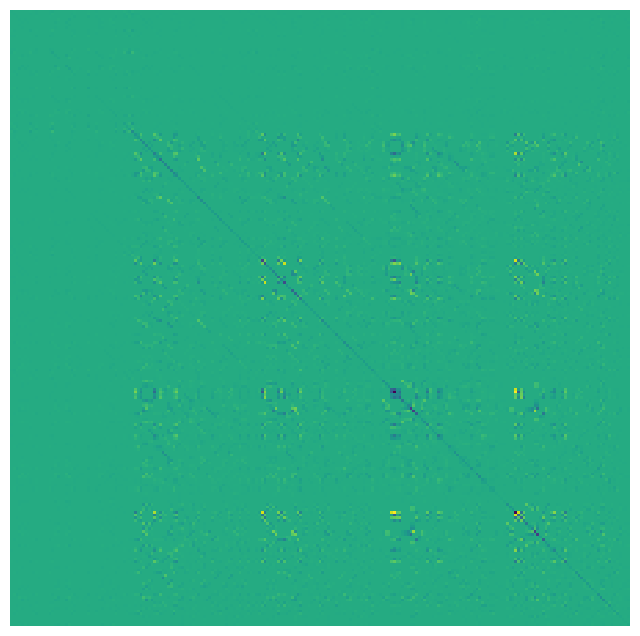

In [114]:
f, ax = plt.subplots(1, 1, figsize=(8, 8))

sns.heatmap(t2_flatten, cmap="viridis", cbar=False, ax=ax, xticklabels=False, yticklabels=False)

<Axes: >

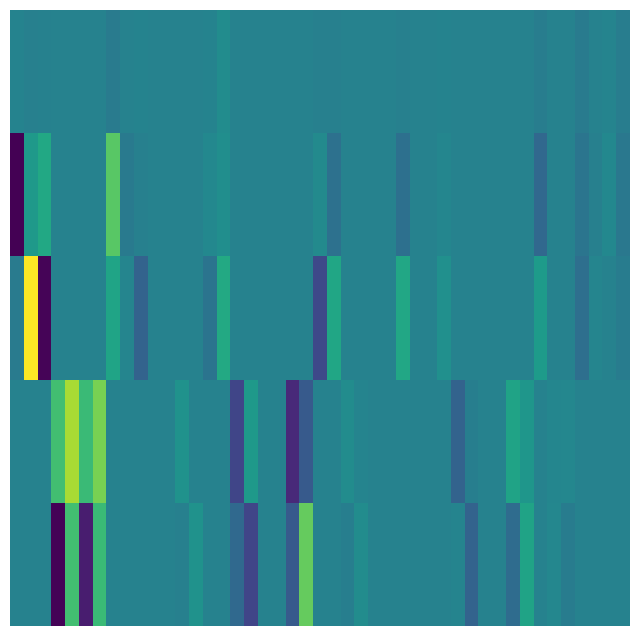

In [115]:
f, ax = plt.subplots(1, 1, figsize=(8, 8))

sns.heatmap(cc["t1"], cmap="viridis", cbar=False, ax=ax, xticklabels=False, yticklabels=False)

In [119]:
sim = compute_ccsd(molecule_fun=hf, molecule_kwargs={"perturb": True})

In [120]:
sim

{'atoms': array(['F', 'H'], dtype=object),
 'positions': array([[0.       , 0.       , 0.       ],
        [0.8356392, 0.       , 0.       ]], dtype=float32),
 'kinetic_energy': array([[ 3.6984577e+01, -2.1285750e-01,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  7.6140137e-03],
        [-2.1285750e-01,  1.0379955e+00,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  1.7714866e-01],
        [ 0.0000000e+00,  0.0000000e+00,  3.2480147e+00,  0.0000000e+00,
          0.0000000e+00,  3.4381032e-01],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  3.2480147e+00,
          0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
          3.2480147e+00,  0.0000000e+00],
        [ 7.6140137e-03,  1.7714866e-01,  3.4381032e-01,  0.0000000e+00,
          0.0000000e+00,  7.6003188e-01]], dtype=float32),
 'nuc_attraction': array([-7.7642838e+01, -9.3275185e+00, -1.2165520e+01, -1.8131776e-02,
        -2.1058236e-01, -1